In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import colorsys

cell_types = ['HEK293T', 'HeLa']

# set the font size
plt.rcParams.update({'font.size': 7})
# set Helvetica globally
plt.rcParams['font.family'] = 'Helvetica'

prefix = "lib2_polysome"

import matplotlib.cm as cm

tab10 = cm.get_cmap('tab10')
tab20b = cm.get_cmap('tab20b')

# Use tab10 for main colors, and generate slightly off-colors by shifting the hue for 5UTR
def shift_color(color, amount=0.15):
    r, g, b, a = color
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    h = (h + amount) % 1.0
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return (r2, g2, b2, a)

cell_line_colors = {
    "HEK293T_3UTR": tab10(0),
    "HEK293T_5UTR": shift_color(tab10(0), 0.15),
    "HeLa_3UTR": tab10(4),
    "HeLa_5UTR": shift_color(tab10(4), 0.15),
}

C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\2521681819.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap('tab10')
C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\2521681819.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20b = cm.get_cmap('tab20b')


In [2]:
def get_common_index(series1, series2):
    series1 = series1.dropna()
    series2 = series2.dropna()
    common_index = series1.index.intersection(series2.index)
    return series1.loc[common_index], series2.loc[common_index]

## Load and process count data

In [3]:
if prefix == "lib2_polysome":
    controls = {
        "P96.2_3UTR": 1,
        "P96.4_3UTR": 1,
        "P96.5_3UTR": 0.1,
        "P96.6_3UTR": 0.1,
        "P96.7_3UTR": 0.01,
        "P96.8_3UTR": 0.01,
        "P96.9_3UTR": 0.001,
        "P96.10_3UTR": 0.001,
        "P96.11_3UTR": 0.0001,
        "P96.14_3UTR": 0.0001,
    }
elif prefix == "lib1_polysome":
    controls = {
        "P88.1_3UTR": 1,
        "P88.3_3UTR": 1,
        "P88.5_3UTR": 0.1,
        "P88.6_3UTR": 0.1,
        "P88.7_3UTR": 0.01,
        "P88.8_3UTR": 0.01,
        "P88.9_3UTR": 0.001,
        "P88.10_3UTR": 0.001,
        "P88.11_3UTR": 0.0001,
        "P88.12_3UTR": 0.0001,
    }

In [4]:
if prefix == "lib2_polysome":
    count_df = pd.read_csv('../count_data/overall_lib2_processing/counts_out/lib2-polysome-counts-processed.csv', index_col=0)
elif prefix == "lib1_polysome":
    count_df = pd.read_csv('../count_data/overall_lib1_processing/counts_out/lib1-polysome-counts-processed.csv', index_col=0)
count_df = count_df.fillna(0)
count_df.columns = [column.replace('polysome_lib2_3UTR_', '3UTR_') for column in count_df.columns]
count_df.columns = [column.replace('polysome_lib2_5UTR_', '5UTR_') for column in count_df.columns]
count_df.columns = [column.replace('H293T', 'HEK293T') for column in count_df.columns]

In [5]:
if prefix == "lib2_polysome":
    mirna_index = list(count_df[count_df.index.str.lower().str.contains("mirna")].index)
    lib2_ctrl_index = list(count_df[count_df.index.str.contains("0_lib2_controls")].index)
    ctrl_index = list(count_df[count_df.index.str.contains("P96")].index)
    count_df= count_df[count_df.index.isin(mirna_index + lib2_ctrl_index + ctrl_index)]
    count_df = count_df.dropna()
elif prefix == "lib1_polysome":
    mirna_index = list(count_df[count_df.index.str.lower().str.contains("mirna")].index)
    ctrl_index = list(count_df[count_df.index.str.contains("P88")].index)
    count_df= count_df[count_df.index.isin(mirna_index + ctrl_index)]
    count_df = count_df.dropna()

In [6]:
if prefix == "lib2_polysome":
    sample_translation = {
        "HEK293T": {
            'S1': 'bulk',
            'S2': 'peak_0',
            'S3': 'peak_1',
            'S4': 'peak_2',
            'S5': 'peak_3.1',
            'S6': 'peak_4',
            'S7': 'peak_4.9',
            'S8': 'peak_5.67',
            'S9': 'peak_6.5',
            'S10': 'peak_7.5',
            'S11': 'peak_8.5',
            'S12': 'peak_9.5',
            # 'S13': 'peak_11',
        },
        "HeLa": {
            'S1': 'bulk',
            'S2': 'peak_0',
            'S3': 'peak_1',
            'S4': 'peak_2',
            'S5': 'peak_3',
            'S6': 'peak_4',
            'S7': 'peak_5',
            'S8': 'peak_6.1',
            'S9': 'peak_7',
            'S10': 'peak_8',
            'S11': 'peak_9',
            # 'S12': 'peak_10',
            # 'S13': 'peak_11',
        }
    }
elif prefix == "lib1_polysome":
    sample_translation = {
        "HEK293T": {
            'S1': 'bulk',
            'S2': 'peak_0',
            'S3': 'peak_1',
            'S4': 'peak_2',
            'S5': 'peak_3.1',
            'S6': 'peak_4',
            'S7': 'peak_4.9',
            'S8': 'peak_5.67',
            'S9': 'peak_6.5',
            'S10': 'peak_7.5',
            'S11': 'peak_8.5',
            'S12': 'peak_9.5',
            # 'S13': 'peak_11',
        },
        "HeLa": { 
            'S1': 'bulk',
            'S2': 'peak_0',
            'S3': 'peak_1',
            'S4': 'peak_2',
            'S5': 'peak_3',
            'S6': 'peak_4',
            'S7': 'peak_5',
            'S8': 'peak_5.9',
            'S9': 'peak_6.9',
            'S10': 'peak_7.5',
            'S11': 'peak_9',
            # 'S12': 'peak_10',
            # 'S13': 'peak_11',
        }
    }

ribosome_loads= {
    "HEK293T": [float(value.replace("peak_", "")) for value in sample_translation["HEK293T"].values() if "peak_" in value],
    "HeLa": [float(value.replace("peak_", "")) for value in sample_translation["HeLa"].values() if "peak_" in value],
}

if prefix == "lib2_polysome":
    reference_amounts = { # this is how many samples were pooled for each fraction
        "HEK293T": {
            'S1': 1,
            'S2': 3,
            'S3': 3,
            'S4': 2,
            'S5': 2,
            'S6': 1,
            'S7': 1,
            'S8': 1,
            'S9': 1,
            'S10': 1,
           'S11': 1,
           'S12': 1,
           'S13': 1,
        },
        "HeLa": {
            'S1': 1,
            'S2': 3,
            'S3': 2,
            'S4': 2,
            'S5': 2,
            'S6': 1,
            'S7': 2,
            'S8': 1,
            'S9': 1,
            'S10': 1,
           'S11': 1,
           'S12': 1,
           'S13': 1,
        }
    }
elif prefix == "lib1_polysome":
    reference_amounts = {
        "HEK293T": {
            'S1': 1,
            'S2': 3,
            'S3': 3,
            'S4': 2,
            'S5': 2,
            'S6': 1,
            'S7': 1,
            'S8': 1,
            'S9': 1,
            'S10': 1,
           'S11': 1,
           'S12': 1,
           'S13': 1,
        },
        "HeLa": {
            'S1': 1,
            'S2': 3,
            'S3': 2,
            'S4': 2,
            'S5': 2,
            'S6': 2,
            'S7': 1,
            'S8': 1,
            'S9': 1,
            'S10': 1,
           'S11': 1,
           'S12': 1,
           'S13': 1,
        }
    } 

In [15]:
normalization_method = 'reference_adjusted' # options: 'reference_adjusted', 'total_umis'
fractions = 'start_zero' # options: 'start_zero', 'no_zero'

plot_folder = f"plots_{prefix}_{normalization_method}_{fractions}"
os.makedirs(plot_folder, exist_ok=True)

In [16]:
columns_3UTR = count_df.columns[count_df.columns.str.contains('3UTR')]
columns_5UTR = count_df.columns[count_df.columns.str.contains('5UTR')]

AttributeError: Can only use .str accessor with Index, not MultiIndex

In [ ]:
# get the references from the 3UTR data
for column in columns_5UTR:
    count_df.loc[controls.keys(), column] = count_df.loc[controls.keys(), column.replace('5UTR_', '3UTR_')] 

In [ ]:
# make the cell type a two-level column index
tuples = []
for column in count_df.columns:
    if 'HEK293T' in column:
        tuples.append(('HEK293T', "_".join(column.split('_')[1:])))
    elif 'HeLa' in column:
        tuples.append(('HeLa', "_".join(column.split('_')[1:])))
count_df.columns = pd.MultiIndex.from_tuples(tuples)

# add another level for 3UTR and 5UTR
tuples = []
for column in count_df.columns:
    cell_type, sample = column
    if '3UTR' in sample:
        tuples.append((cell_type, '3UTR', sample.replace('3UTR_','')))
    elif '5UTR' in sample:
        tuples.append((cell_type, '5UTR', sample.replace('5UTR_','')))
count_df.columns = pd.MultiIndex.from_tuples(tuples)

## Calculate metrics

In [17]:
fraction_reference = {}
relative_abundance = {}
total_umis_non_reference = {}
for column in count_df.columns:
    cell_type, UTR, sample = column
    
    # how many counts in the references?
    counts_reference = count_df.loc[controls.keys(), column]
    reference_sum = counts_reference.sum()
    reference_max = counts_reference.max()
    
    # how many counts in the other sequences?
    other_indices = count_df[~count_df.index.isin(controls.keys())].index.tolist()
    counts_other = count_df.loc[other_indices, column]
    other_sum = counts_other.sum()
    other_max = counts_other.max()
    
    # highest other count divided by highest reference count
    relative_abundance[column] = other_max / reference_max
    
    # fraction of counts in the references
    fraction_reference[column] = reference_sum / (other_sum + reference_sum)
    total_umis_non_reference[column] = other_sum
    
# Create a DataFrame from the dictionaries
metrics_df = pd.DataFrame({
    'Total UMIs (non-reference)': total_umis_non_reference,
    'Fraction of reference': fraction_reference,
    'Relative abundance': relative_abundance
})

# Reset index to convert MultiIndex columns to regular columns
metrics_df = metrics_df.reset_index()
metrics_df.columns = ['Cell Type', 'UTR', 'Sample', 'Total UMIs', 'Fraction Reference', 'Relative Abundance']

os.makedirs('metrics', exist_ok=True)
metrics_df.to_csv(f'metrics/{prefix}_polysome_metrics.csv', index=False)

## Compare to existing stability data

In [18]:
necessary_max = 30
for cell_type in cell_types:
    for UTR in ['3UTR', '5UTR']:
        count_df_sub = count_df[cell_type][UTR]
        mask = count_df_sub.max(axis=1) < necessary_max
        mask[controls.keys()] = False
        count_df.loc[mask, (cell_type, UTR)] = np.nan

C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\3993545210.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  count_df.loc[mask, (cell_type, UTR)] = np.nan
C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\3993545210.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  count_df.loc[mask, (cell_type, UTR)] = np.nan
C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\3993545210.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  count_df.loc[mask, (cell_type, UTR)] = np.nan
C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\3993545210.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  count_df.loc[mask, (cell_type, UTR)] = np.nan


In [19]:
- len(count_df["HeLa"].dropna()) + len(count_df["HeLa"])

51

In [20]:
# load the stability data
if prefix == "lib2_polysome":
    stability_data = pd.read_csv('stability_data/library2_log2fc_with_UMIs_full.csv', index_col=0)
elif prefix == "lib1_polysome":
    stability_data = pd.read_csv('stability_data/lib1_log2fc_combined.csv', index_col=0)
# only retain the cell types we are interested in (one of the cell types should be in the name)
stability_data = stability_data.loc[:, stability_data.columns.str.contains('|'.join(cell_types))]

# get count data in this
stability_data = stability_data.loc[:, stability_data.columns.str.contains('(?=.*count)(?=.*r1)')]
stability_data.columns = [column.replace('count_', '').replace('_r1', '') for column in stability_data.columns]

In [21]:
if prefix == "lib1_polysome":
    columns = stability_data.columns
    new_columns = []
    for column in columns:
        column_split = column.split('_')
        new_column = column_split[1] + '_' + column_split[0]
        new_columns.append(new_column)
    stability_data.columns = new_columns

In [22]:
common_index = stability_data.index.intersection(count_df.index)
common_index = common_index[common_index.str.lower().str.contains('mirna') | common_index.str.lower().str.contains('0_lib2_controls')]
stability_data_filter = stability_data.loc[common_index]
count_df_filter = count_df.loc[common_index]

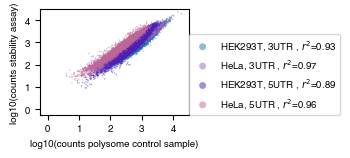

In [23]:
plt.figure(figsize=(2, 1.6))
for column in count_df_filter.columns:
    cell_type, UTR, sample = column
    if sample == "S1":
        current_x = np.log10(count_df_filter[column])
        current_y = np.log10(stability_data_filter[f"{cell_type}_{UTR}"])
        current_x, current_y = get_common_index(current_x, current_y)
        r2 = np.corrcoef(current_x, current_y)[0, 1]**2
        plt.scatter(current_x, current_y, s=1, label=f"{cell_type}, {UTR} "+ r", $r^2$=" + f"{r2:.2f}", alpha=0.5,
                    rasterized=True, edgecolors='none', color=cell_line_colors[cell_type + "_" + UTR])
plt.xlim(-0.25, 4.5)
plt.ylim(-0.25, 4.5)

plt.xlabel("log10(counts polysome control sample)")
plt.ylabel("log10(counts stability assay)")
plt.tight_layout()
plt.legend(loc=[1,0], markerscale=5)  
plt.savefig(os.path.join(plot_folder, "lib2_polysome_vs_plasmid_assay.svg"), dpi=400)

## Normalize to reference

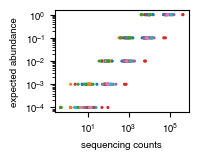

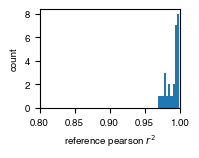

In [24]:
plt.figure(figsize=(2, 1.6))
r2_vals_by_column = {}
for column in count_df.columns:
    if '3UTR' in column:
        x = count_df.loc[controls.keys(), column].fillna(0) + 0.5
        y = list(controls.values())
        r2 = np.corrcoef(np.log10(x), np.log10(y))[0, 1]**2
        r2_vals_by_column[column] = r2
        plt.scatter(x, y, edgecolors="none", s=5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('sequencing counts')
plt.ylabel('expected abundance')
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{prefix}_reference_calibration.svg"))

plt.figure(figsize=(2, 1.6))
plt.hist([r2_vals_by_column[column] for column in r2_vals_by_column.keys()], bins=10)
plt.xlabel(r'reference pearson $r^2$')
plt.xlim(0.8, 1)
plt.ylabel('count')
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{prefix}_reference_calibration_r2_histogram.svg"))

In [25]:
# scale down the relative amount of reference counts based on how many samples were pooled for each fraction
if normalization_method == 'reference_adjusted':
    for cell_type in cell_types:
        for sample in reference_amounts[cell_type]:
            count_df.loc[controls.keys(), (cell_type, '3UTR', sample)] = \
                count_df.loc[controls.keys(), (cell_type, '3UTR', sample)] / reference_amounts[cell_type][sample]
            count_df.loc[controls.keys(), (cell_type, '5UTR', sample)] = \
                count_df.loc[controls.keys(), (cell_type, '5UTR', sample)] / reference_amounts[cell_type][sample]

In [27]:
if normalization_method == 'reference_adjusted':
    def fit_linear_with_intercept(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        a, b = np.polyfit(x, y, 1)
        return a, b

    # spike-in IDs (row index labels)
    control_ids = list(controls.keys())[::-1]
    # true spike-in abundances
    true_abund = pd.Series(controls)[::-1]

    for cell_type in ['HEK293T', 'HeLa']:
        for UTR in ['3UTR', '5UTR']:
            params = {}
            for col in count_df[cell_type][UTR].columns:
                y = count_df[cell_type][UTR].loc[control_ids, col]
                a_j, b_j = fit_linear_with_intercept(true_abund, y)
                params[col] = (a_j, b_j)

            # 0h is the reference time point
            ref_col = count_df[cell_type][UTR].columns[0]
            a_ref, b_ref = params[ref_col]

            for col in count_df[cell_type][UTR].columns:
                a_j, b_j = params[col]
                count_df.loc[:, (cell_type, UTR, col)] = count_df[cell_type][UTR][col] * (a_ref / a_j)
elif normalization_method == 'total_umis':  
    # normalize to total UMIs per sample
    for column in count_df.columns:
        total_umis = count_df[column].sum()
        count_df[column] = count_df[column] / total_umis * 1e6  # normalize to counts per million 

In [28]:
columns_to_retain = []
for column in count_df.columns:
    cell_type, UTR, sample = column
    if sample in sample_translation[cell_type].keys():
        columns_to_retain.append(column)

count_df = count_df[columns_to_retain]

In [29]:
count_df.columns = pd.MultiIndex.from_tuples([
    (cell_type, UTR, sample_translation[cell_type][sample])
    for (cell_type, UTR, sample) in count_df.columns
])

In [30]:
def plot_traces(cell_line, UTR, ref_list):
    plt.figure(figsize=(2.2, 1.8))
    data_df = count_df[cell_line, UTR]
    for ref in ref_list:
        plt.plot(ribosome_loads[cell_line], data_df.loc[ref], label=ref)

    plt.legend(loc="upper right")
    plt.xlim(-0.25, 11.25)
    plt.ylim(0, 20)
    plt.show()

In [31]:
count_df = count_df.loc[:, count_df.columns.get_level_values(2) != 'bulk']

C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\1823703289.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  index = sum_df[cell_type, UTR].index
C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\1823703289.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  plt.scatter(index, sum_df[cell_type, UTR]/sum_df[cell_type, UTR].sum(),


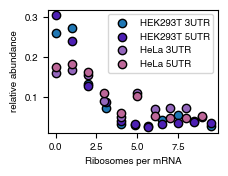

In [32]:
plt.figure(figsize=(2.2, 1.6))

sum_df = count_df.sum(axis=0)

for cell_type in cell_types:
    for UTR in ['3UTR', '5UTR']:
        index = sum_df[cell_type, UTR].index
        index = [float(i.replace('peak_', '')) for i in index]
        plt.scatter(index, sum_df[cell_type, UTR]/sum_df[cell_type, UTR].sum(),
                    edgecolor='black', color=cell_line_colors[f"{cell_type}_{UTR}"],
                    label=f"{cell_type} {UTR}")
        
plt.xlabel("Ribosomes per mRNA")
plt.ylabel("relative abundance")
plt.legend(loc="upper right", fontsize=7)
plt.savefig(os.path.join(plot_folder, f"{prefix}_overall_distribution.svg"), dpi=400)

C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\4009146250.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_df = count_df[cell_line, UTR]


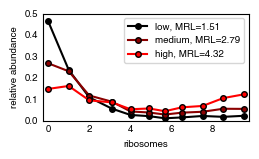

In [33]:
cell_line = "HEK293T"
UTR = "5UTR"
ref_list = ['10_miRNA_full_repeat_x6_43', '5.2_miRNA_let-7a-5p_wob18', '40_miRNA_mut_repeat_x6_13']

plt.figure(figsize=(2.6, 1.6))
data_df = count_df[cell_line, UTR]
labels = ['low', 'medium', 'high']
colors = ["black", "darkred", "red"]
for i, ref in enumerate(ref_list):
    MRL = (ribosome_loads[cell_line]*data_df.loc[ref]/data_df.loc[ref].sum()).sum()
    plt.plot(ribosome_loads[cell_line], data_df.loc[ref]/data_df.loc[ref].sum(),
             label=f"{labels[i]}, MRL={MRL:.2f}", color=colors[i], marker='o', markersize=4, markeredgecolor='black')

plt.legend(loc="upper right")
plt.ylabel('relative abundance')
plt.xlabel('ribosomes')
plt.tick_params(axis='both', length=0)
plt.xlim(-0.25, 9.75)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{cell_line}_{UTR}_example_traces.svg"))

## Calculate MRL

In [34]:
if fractions == 'start_zero':
    start_index = 1
elif fractions == 'no_zero':
    start_index = 2

relevant_mrl_cols = {
    "HEK293T": list(sample_translation['HEK293T'].values())[start_index:],  # exclude bulk
    "HeLa": list(sample_translation['HeLa'].values())[start_index:],  # exclude bulk
}

In [35]:
MRL_df = pd.DataFrame(index=count_df.index, columns=["3UTR_HEK293T", "5UTR_HEK293T", "3UTR_HeLa", "5UTR_HeLa"])
for col in MRL_df.columns:
    UTR, cell_type = col.split('_')
    relevant_cols = relevant_mrl_cols[cell_type]
    for index in MRL_df.index:
        MRL = (np.array(ribosome_loads[cell_type][start_index-1:]) * count_df.loc[index, (cell_type, UTR, relevant_cols)].values / 
               count_df.loc[index, (cell_type, UTR, relevant_cols)].sum()).sum()
        MRL_df.loc[index, col] = MRL
MRL_df = MRL_df.dropna()  

In [36]:
tuples = []
for col in MRL_df.columns:
    col = col.split('_')
    tuples.append((col[1], col[0]))
MRL_df.columns = pd.MultiIndex.from_tuples(tuples)
MRL_df.columns.names = ["cell type", "UTR"]

In [37]:
MRL_long = MRL_df.reset_index().melt(id_vars=[('Reference', "")])
MRL_long.columns = ['reference', 'cell type', 'UTR', 'MRL']

In [38]:
MRL_long['UTR'] = MRL_long['UTR'].replace({'3UTR': '3\' UTR', '5UTR': '5\' UTR'})

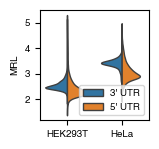

In [39]:
plt.figure(figsize=(1.6, 1.5))

sns.violinplot(data=MRL_long, x='cell type', y='MRL', hue='UTR', split=True, inner=None, linewidth=1)
plt.legend(title="")
plt.xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{prefix}_polysome_MRL_violin_overall.svg"))

## Look at ATGs

In [40]:
mirbase_df = pd.read_csv("other_info/mirbase_extended.csv", index_col=0)

if prefix == "lib2_polysome":
    all_designs = pd.read_csv("design_files_lib2/all_lib2_designs.csv", index_col=0)
    all_designs = all_designs.loc[all_designs.index.isin(MRL_df.index)]
elif prefix == "lib1_polysome":
    all_designs = pd.read_csv("design_files_lib1/all_lib1_designs.csv", index_col=0)
    all_designs = all_designs.loc[all_designs.index.isin(MRL_df.index)]
    raise NotImplementedError("Design merging for lib1 not implemented yet")

In [41]:
upstream = "CTCTTCCTCATCTCCGGGCCTTTCGACCTGCAGCCCTTTCCCTAC"
downstream = "AGACCTCAAAGCTTGGCAATCCGGTACTGTTGGTAAAGCCACCATG"
all_designs['seq'] = upstream + all_designs['seq'] + downstream

# def find_ATG_positions(seq):
#     """Get the positions of all ATGs in a sequence"""
#     return [i for i in range(len(seq)-2) if seq[i:i+3] == "ATG"]

# def find_STOP_positions(seq):
#     """Get the positions of all STOP codons in a sequence"""
#     return [i for i in range(len(seq)-2) if seq[i:i+3] in ["TAA", "TAG", "TGA"]]

def find_uorfs(seq: str):
    """
    Identify upstream open reading frames (uORFs) in a DNA sequence.

    Rules:
    - A new ATG is only considered if the previous uORF is terminated.
    - Returns both terminated and non-terminated uORFs.

    Returns:
        atg_positions: list of all start codon positions
        stop_positions: list of all stop codon positions
        terminated_uorfs: list of (start, stop) tuples for in-frame terminated uORFs
        non_terminated_uorfs: list of (start, end_of_seq) tuples for uORFs with no in-frame stop
    """
    seq = seq.upper()
    atg_positions = [i for i in range(len(seq) - 4) if seq[i:i+3] == "ATG"]
    stop_positions = [i for i in range(len(seq) - 4) if seq[i:i+3] in ["TAA", "TAG", "TGA"]]

    terminated_uorfs = []
    non_terminated_uorfs = []

    last_stop_end = -1  # ensures next ATG can only start after this

    for start in atg_positions:
        if start <= last_stop_end:
            continue  # skip ATGs inside a previous uORF

        # find in-frame stop codons after this ATG
        in_frame_stops = [stop for stop in stop_positions if stop > start and (stop - start) % 3 == 0]
        if in_frame_stops:
            first_stop = min(in_frame_stops)
            terminated_uorfs.append((start, first_stop))
            last_stop_end = first_stop + 3  # move past the stop codon
        else:
            non_terminated_uorfs.append(start)
            last_stop_end = len(seq)  # no further uORFs after this

    return atg_positions, stop_positions, terminated_uorfs, non_terminated_uorfs

# all_designs["ATG_positions"] = all_designs["seq"].apply(find_ATG_positions)
# all_designs["STOP_positions"] = all_designs["seq"].apply(find_STOP_positions)
all_designs[["ATG_positions", "STOP_positions", "terminated_uorfs", "non_terminated_uorfs"]] = \
    all_designs["seq"].apply(lambda seq: pd.Series(find_uorfs(seq)))

In [42]:
all_designs = all_designs.reset_index().rename(columns={"index": "reference"})

In [43]:
MRL_long = pd.merge(MRL_long, all_designs, on='reference', how='left')
MRL_long = MRL_long.dropna(subset=['seq'])
MRL_long['Random_sampling'] = np.random.rand(len(MRL_long)) > 0.5

In [44]:
control_seqs = MRL_long[MRL_long['reference'].str.contains('lib2_control', case=False)]['reference'].unique().tolist()

In [45]:
MRL_long = MRL_long.copy()

In [46]:
MRL_long['has_uORF'] = MRL_long['terminated_uorfs'].apply(lambda x: len(x) > 0)
MRL_long['has_nont_uORF'] = MRL_long['non_terminated_uorfs'].apply(lambda x: len(x) > 0)

C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\1795918765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=control_df, x='group', y='MRL', palette="Set2", size=3)
c:\Users\loesi\anaconda3\envs\Bio\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\loesi\anaconda3\envs\Bio\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\loesi\AppData\Local\Temp\ipykernel_34992\1795918765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and

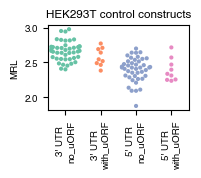

c:\Users\loesi\anaconda3\envs\Bio\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


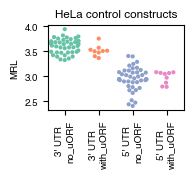

In [47]:
for cell_type in cell_types:
    plt.figure(figsize=(2, 1.8))
    # Convert data to long format for seaborn
    control_df = MRL_long[(MRL_long['reference'].isin(control_seqs)) & (MRL_long['cell type'] == cell_type)].copy()
    control_df['group'] = control_df['UTR'] + (control_df['terminated_uorfs'].str.len() > 0).map({True: '\nwith_uORF', False: '\nno_uORF'})
    sns.swarmplot(data=control_df, x='group', y='MRL', palette="Set2", size=3)
    plt.xticks(rotation=90)
    plt.xlabel("")
    plt.title(f"{cell_type} control constructs")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_folder, f"{prefix}_polysome_control_MRL_violin_{cell_type}.svg"), dpi=300)

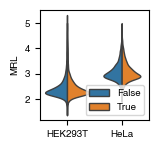

In [48]:
plt.figure(figsize=(1.6, 1.5))

subset = MRL_long[(MRL_long['UTR'] == "5' UTR")]

sns.violinplot(data=subset, x='cell type', y='MRL', hue='Random_sampling', split=True, inner=None, linewidth=1)
plt.legend(title="")
plt.xlabel("")
plt.tight_layout()
plt.show()
#plt.savefig(os.path.join(plot_folder, f"{prefix}_polysome_MRL_violin_overall.svg"))

In [51]:
stability_df = pd.read_csv("../ActionmycinD_time_course/plasmid_assay_data/library2_normalized_stability_data.csv", index_col=0)
stability_df = stability_df[["HEK293T", "HeLa", "HEK293T_5UTR", "HeLa_5UTR"]]
stability_df = stability_df.rename(columns={
    "HEK293T": "HEK293T_3UTR",
    "HeLa": "HeLa_3UTR",
})

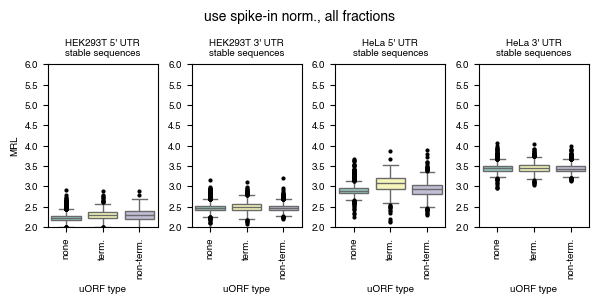

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(6, 3))
axes = axes.flatten()

i = 0
for cell_line in cell_types:
    for UTR in ["5' UTR", "3' UTR"]:
        ax = axes[i]
        
        stable_sequences = stability_df[f"{cell_line}_" + UTR.replace("' ", '')]
        stable_sequences = stable_sequences[
            (stable_sequences > 0.66) &
            (stable_sequences < 1.5)
        ]

        hek_stable_mrl = MRL_long[
            (MRL_long["cell type"] == cell_line) &
            (MRL_long["UTR"] == UTR) &
            (MRL_long['reference'].isin(stable_sequences.index))
            ]

        data_no_uorf = hek_stable_mrl[
            (hek_stable_mrl['has_uORF'] == False) &
            (hek_stable_mrl['has_nont_uORF'] == False)
            ]['MRL']
        data_term_uorf = hek_stable_mrl[
            (hek_stable_mrl['has_uORF'] == True)
            ]['MRL']
        data_nont_uorf = hek_stable_mrl[
            (hek_stable_mrl['has_nont_uORF'] == True) &
            (hek_stable_mrl['has_uORF'] == False)
            ]['MRL']

        data_to_plot = [data_no_uorf, data_term_uorf, data_nont_uorf]
        labels = ['none', 'term.', 'non-term.']

        # Build a DataFrame with each group as a column (handles unequal lengths and ensures numeric dtype)
        df = pd.DataFrame()
        for lbl, s in zip(labels, data_to_plot):
            df[lbl] = pd.to_numeric(s, errors='coerce').dropna().reset_index(drop=True)

        sns.boxplot(
            data=df,
            flierprops={
                "marker": "o",
                "markersize": 3,
                "markerfacecolor": "black",
                "markeredgecolor": "none"
            },
            palette="Set3",
            ax=ax
        )
        ax.set_xticks(ticks=range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, ha='center')
        ax.set_xlabel('uORF type')
        if i == 0:
            ax.set_ylabel('MRL')
        ax.set_title(f'{cell_line} {UTR}\nstable sequences', fontsize=7)
        ax.set_ylim(2, 6)
        i += 1

if normalization_method == 'reference_adjusted':
    norm_title = 'use spike-in norm.'
if normalization_method == 'total_umis':
    norm_title = 'tpm norm.'
if fractions == 'start_zero':
    fractions_title = ', all fractions'
if fractions == 'no_zero':
    fractions_title = ', no 0 fraction'
fig.suptitle(norm_title + fractions_title, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{prefix}_polysome_HEK293T_stable_uORF_effect.svg"), dpi=300)

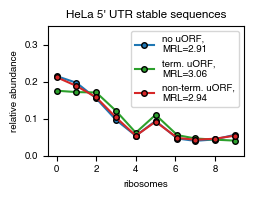

In [53]:
cell_type = "HeLa"
UTR = "5' UTR"

stable_sequences = stability_df[f"{cell_line}_" + UTR.replace("' ", '')]
stable_sequences = stable_sequences[
    (stable_sequences > 0.66) &
    (stable_sequences < 1.5)
]

hek_stable_mrl = MRL_long[
    (MRL_long["cell type"] == cell_line) &
    (MRL_long["UTR"] == UTR) &
    (MRL_long['reference'].isin(stable_sequences.index))
    ]
no_uorf = hek_stable_mrl[
    (hek_stable_mrl['has_uORF'] == False) &
    (hek_stable_mrl['has_nont_uORF'] == False)
    ]['reference'].tolist()
term_uorf = hek_stable_mrl[
    (hek_stable_mrl['has_uORF'] == True)
    ]['reference'].tolist()
nont_uorf = hek_stable_mrl[
    (hek_stable_mrl['has_nont_uORF'] == True) &
    (hek_stable_mrl['has_uORF'] == False)
    ]['reference'].tolist()

count_df_subset = count_df[cell_type][UTR.replace("' ", '')]
means_no_uorf = count_df_subset.loc[no_uorf].mean()
means_term_uorf = count_df_subset.loc[term_uorf].mean()
means_nont_uorf = count_df_subset.loc[nont_uorf].mean()

plt.figure(figsize=(2.6, 2))
labels = ['no uORF', 'term. uORF', 'non-term. uORF']
colors = ["tab:blue", "tab:green", "tab:red"]
for i, means in enumerate([means_no_uorf, means_term_uorf, means_nont_uorf]):
    MRL = (ribosome_loads[cell_type]*means/means.sum()).sum()
    plt.plot(ribosome_loads[cell_type], means/means.sum(),
             label=f"{labels[i]},\nMRL={MRL:.2f}", color=colors[i], marker='o', markersize=4, markeredgecolor='black')
plt.ylabel('relative abundance')
plt.xlabel('ribosomes')
plt.legend(loc="upper right")
plt.ylim(0, 0.35)
plt.title(f"{cell_type} {UTR} stable sequences")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{cell_type}_{UTR}_uORF_effect_traces.svg"))

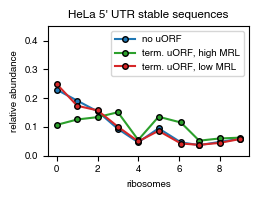

In [54]:
cell_type = "HeLa"
UTR = "5' UTR"

stable_sequences = stability_df[f"{cell_line}_" + UTR.replace("' ", '')]
stable_sequences = stable_sequences[
    (stable_sequences > 0.66) &
    (stable_sequences < 1.5)
]

hek_stable_mrl = MRL_long[
    (MRL_long["cell type"] == cell_line) &
    (MRL_long["UTR"] == UTR) &
    (MRL_long['reference'].isin(stable_sequences.index))
    ]
no_uorf = hek_stable_mrl[
    (hek_stable_mrl['has_uORF'] == False) &
    (hek_stable_mrl['has_nont_uORF'] == False)
    ]
term_uorf = hek_stable_mrl[
    (hek_stable_mrl['has_uORF'] == True)
    ]
nont_uorf = hek_stable_mrl[
    (hek_stable_mrl['has_nont_uORF'] == True) &
    (hek_stable_mrl['has_uORF'] == False)
    ]

references = [
    no_uorf.iloc[0]['reference'],
    term_uorf[term_uorf["MRL"] > 3.7]['reference'].iloc[0],
    term_uorf[term_uorf["MRL"] < 3.0]['reference'].iloc[0]
]

plt.figure(figsize=(2.6, 2))
labels = ['no uORF', 'term. uORF, high MRL', 'term. uORF, low MRL']
colors = ["tab:blue", "tab:green", "tab:red"]
for i, reference in enumerate(references):
    counts = count_df[cell_type][UTR.replace("' ", '')].loc[reference]
    counts = counts / counts.sum()
    plt.plot(ribosome_loads[cell_type], counts,
             label=f"{labels[i]}", color=colors[i], marker='o', markersize=4, markeredgecolor='black')
plt.ylabel('relative abundance')
plt.xlabel('ribosomes')
plt.legend(loc="upper right")
plt.ylim(0, 0.45)
plt.title(f"{cell_type} {UTR} stable sequences")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{cell_type}_{UTR}_trace_examples.svg"))

# single miRNA

In [55]:
mirna_expression = pd.read_csv("mirna_data/Alles_Keller_combined_expression_wo_crosstalk_scaled.csv", index_col=0)

In [56]:
no_uorf = set(MRL_long[MRL_long['has_uORF'] == False]['reference'].tolist())

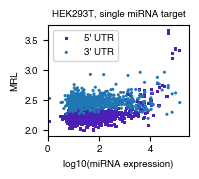

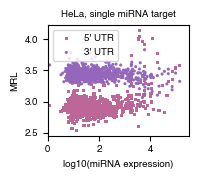

In [57]:
design_file_mirna = pd.read_csv("design_files_lib2/1_mirna_full_single_high_conf.csv", index_col=0)
MRL_df_no_ATG_single_mirna = MRL_df.loc[MRL_df.index.isin(design_file_mirna.index)].copy()
#MRL_df_no_ATG_single_mirna = MRL_df_no_ATG_single_mirna.loc[MRL_df_no_ATG_single_mirna.index.isin(no_uorf)]
MRL_df_no_ATG_single_mirna["miRNA"] = design_file_mirna["miRNA1"]
MRL_df_no_ATG_single_mirna = MRL_df_no_ATG_single_mirna.set_index("miRNA")

for cell_type in cell_types:
    plt.figure(figsize=(2, 1.8))
    common_index = MRL_df_no_ATG_single_mirna.index.intersection(mirna_expression.index)
    plt.scatter(mirna_expression.loc[common_index, "HEK293T"], MRL_df_no_ATG_single_mirna.loc[common_index, (cell_type, "5UTR")],
        label=f"5' UTR", s=5, color=cell_line_colors[cell_type + "_5UTR"], marker='s', rasterized=True, edgecolors='none')
    plt.scatter(mirna_expression.loc[common_index, "HEK293T"], MRL_df_no_ATG_single_mirna.loc[common_index, (cell_type, "3UTR")],
        label=f"3' UTR", s=5, color=cell_line_colors[cell_type + "_3UTR"], marker='o', rasterized=True, edgecolors='none')
    plt.legend(loc="upper left")
    plt.xlim(0, 5.5)
    plt.xlabel("log10(miRNA expression)")
    plt.ylabel("MRL")
    plt.title(f"{cell_type}, single miRNA target", fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_folder, f"expression_vs_MRL_single_target_{cell_type}.svg"), dpi=300)

### single mirna full

In [58]:
def convert_to_long(df):
    df = df.reset_index().copy()

    # --- 1. Flatten MultiIndex columns ---
    df.columns = [
        c[0] if (isinstance(c, tuple) and (pd.isna(c[1]) or c[1] == '')) else '_'.join(map(str, c))
        for c in df.columns
    ]

    # --- 2. Identify id and value columns ---
    id_cols = [c for c in df.columns if c in ['miRNA', 'repeats']]
    value_cols = [c for c in df.columns if ('_' in c and any(u in c for u in ['UTR', '3UTR', '5UTR']))]

    # --- 3. Convert value columns back to a MultiIndex with levels ['cell_type','UTR'] ---
    split_cols = [tuple(c.split('_', 1)) for c in value_cols]
    value_df = df[value_cols].copy()
    value_df.columns = pd.MultiIndex.from_tuples(split_cols, names=['cell_type', 'UTR'])

    # --- 4. Stack to long format ---
    long_vals = (
        value_df
        .stack(['cell_type', 'UTR'], future_stack=True)
        .rename('MRL')
        .reset_index()  # includes the original row index
    )

    # --- 5. Add miRNA and repeats columns by row alignment ---
    id_df = df[id_cols].iloc[long_vals['level_0']].reset_index(drop=True)

    # --- 6. Combine and reorder ---
    df = pd.concat(
        [id_df, long_vals[['cell_type', 'UTR', 'MRL']].reset_index(drop=True)],
        axis=1
    )

    # Final tidy order
    df = df[
        ['miRNA', 'repeats', 'cell_type', 'UTR', 'MRL']
    ]
    
    return df

In [59]:
design_files_single_mirna = {
    "1x": pd.read_csv("design_files_lib2/1_mirna_full_single_high_conf.csv", index_col=0),
    "2x": pd.read_csv("design_files_lib2/6_miRNA_full_repeat_x2.csv", index_col=0),
    "3x": pd.read_csv("design_files_lib2/7_miRNA_full_repeat_x3.csv", index_col=0),
    "4x": pd.read_csv("design_files_lib2/8_miRNA_full_repeat_x4.csv", index_col=0),
    "5x": pd.read_csv("design_files_lib2/9_miRNA_full_repeat_x5.csv", index_col=0),
    "6x": pd.read_csv("design_files_lib2/10_miRNA_full_repeat_x6.csv", index_col=0),
}

In [60]:
for key, df in design_files_single_mirna.items():
    df['repeats'] = key
design_files_single_mirna = pd.concat(design_files_single_mirna.values())

In [61]:
MRL_df_no_ATG_single_mirna = MRL_df.loc[MRL_df.index.isin(design_files_single_mirna.index)].copy()
MRL_df_no_ATG_single_mirna["miRNA"] = design_files_single_mirna.loc[design_files_single_mirna.index, "miRNA1"]

MRL_df_no_ATG_single_mirna['repeats'] = design_files_single_mirna.loc[MRL_df_no_ATG_single_mirna.index, 'repeats']
MRL_df_no_ATG_single_mirna = MRL_df_no_ATG_single_mirna.set_index(['miRNA', 'repeats'])

val_counts = MRL_df_no_ATG_single_mirna.index.get_level_values('miRNA').value_counts()
val_counts = val_counts[val_counts == 6].index
MRL_df_no_ATG_single_mirna = MRL_df_no_ATG_single_mirna.loc[val_counts]

MRL_long = convert_to_long(MRL_df_no_ATG_single_mirna)

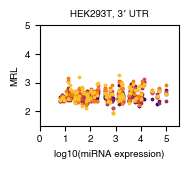

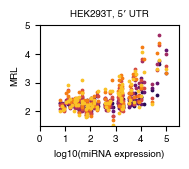

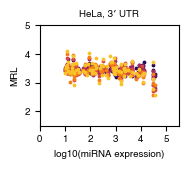

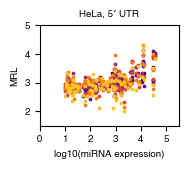

In [62]:
ylim = {
    "HEK293T": [2, 5],
    "HeLa": [2.5, 6],
}
for cell_type in cell_types:
    for UTR in ["3UTR", "5UTR"]:
        colors = sns.color_palette("inferno", n_colors=6)
        plt.figure(figsize=(1.9, 1.7))
        for repeat_index, repeat in enumerate(["1x", "2x", "3x", "4x", "5x", "6x"]):
            current_data = MRL_df_no_ATG_single_mirna.xs(repeat, level='repeats')
            common_index = current_data.index.intersection(mirna_expression.index)
            plt.scatter(mirna_expression.loc[common_index, cell_type], current_data.loc[common_index, (cell_type, UTR)],
                label=f"{repeat}", s=3, color=colors[repeat_index], marker='o')

        #plt.legend(loc="upper left", ncol=2)
        plt.xticks([0, 1, 2, 3, 4, 5])
        plt.xlim(0, 5.5)
        plt.ylim(1.5, 5)
        plt.xlabel("log10(miRNA expression)")
        plt.ylabel("MRL")
        plt.title(f"{cell_type}, {'3′ UTR' if UTR == '3UTR' else '5′ UTR'}", fontsize=7)
        plt.tight_layout()
        plt.savefig(os.path.join(plot_folder, f"expression_vs_MRL_repeats_{cell_type}_{UTR}.svg"))

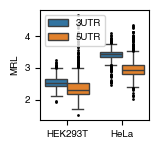

In [63]:
plt.figure(figsize=(1.6, 1.5))

sns.boxplot(
    data=MRL_long,
    x='cell_type',
    y='MRL',
    hue='UTR',
    linewidth=1,
    flierprops={'marker': 'o', 'markersize': 2, 'markeredgecolor': 'none', 'markerfacecolor': 'black'},
    showfliers=True
)
plt.legend(title="")
plt.xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{prefix}_polysome_MRL_violin_overall.svg"))

## bulged sites

In [64]:
design_files_mut = {
    #"1x": pd.read_csv("design_files_lib2/5_miRNA_single_mut.csv", index_col=0),
    "2x": pd.read_csv("design_files_lib2/36_miRNA_mut_repeat_x2.csv", index_col=0),
    "3x": pd.read_csv("design_files_lib2/37_miRNA_mut_repeat_x3.csv", index_col=0),
    "4x": pd.read_csv("design_files_lib2/38_miRNA_mut_repeat_x4.csv", index_col=0),
    "5x": pd.read_csv("design_files_lib2/39_miRNA_mut_repeat_x5.csv", index_col=0),
    "6x": pd.read_csv("design_files_lib2/40_miRNA_mut_repeat_x6.csv", index_col=0),
}

In [65]:
for key, df in design_files_mut.items():
    df['repeats'] = key
design_files_mut = pd.concat(design_files_mut.values())

In [66]:
MRL_df_no_ATG_single_mirna = MRL_df.loc[MRL_df.index.isin(design_files_mut.index)].copy()
MRL_df_no_ATG_single_mirna["miRNA"] = design_files_mut.loc[design_files_mut.index, "orig_mi"]

MRL_df_no_ATG_single_mirna['repeats'] = design_files_mut['repeats']
MRL_df_no_ATG_single_mirna = MRL_df_no_ATG_single_mirna.set_index(['miRNA', 'repeats'])

In [67]:
MRL_df_no_ATG_single_mirna_long = convert_to_long(MRL_df_no_ATG_single_mirna)

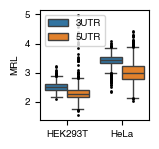

In [68]:
plt.figure(figsize=(1.6, 1.5))

sns.boxplot(
    data=MRL_df_no_ATG_single_mirna_long,
    x='cell_type',
    y='MRL',
    hue='UTR',
    linewidth=1,
    flierprops={'marker': 'o', 'markersize': 2, 'markeredgecolor': 'none', 'markerfacecolor': 'black'},
    showfliers=True
)
plt.legend(title="")
plt.xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(plot_folder, f"{prefix}_polysome_MRL_violin_overall.svg"))

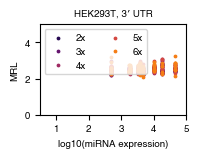

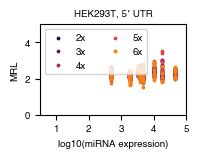

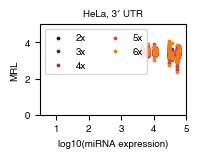

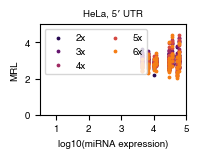

In [69]:
for cell_type in cell_types:
    for UTR in ["3UTR", "5UTR"]:
        colors = sns.color_palette("inferno", n_colors=6)
        plt.figure(figsize=(2, 1.6))
        for repeat_index, repeat in enumerate(["2x", "3x", "4x", "5x", "6x"]):
            current_data = MRL_df_no_ATG_single_mirna.xs(repeat, level='repeats')
            common_index = current_data.index.intersection(mirna_expression.index)
            plt.scatter(mirna_expression.loc[current_data.index.get_level_values('miRNA'), cell_type], 
                        current_data.loc[:, (cell_type, UTR)],
                label=f"{repeat}", s=3, color=colors[repeat_index], marker='o')

        plt.legend(loc="upper left", ncol=2)
        plt.xlim(0.5, 5)
        plt.ylim(0, 5)
        plt.xlabel("log10(miRNA expression)")
        plt.ylabel("MRL")
        plt.title(f"{cell_type}, {'3′ UTR' if UTR == '3UTR' else '5′ UTR'}", fontsize=7)
        plt.tight_layout()
        plt.savefig(os.path.join(plot_folder, f"MUT_expression_vs_MRL_repeats_{cell_type}_{UTR}.svg"))